In [1]:
!pip install gymnasium[atari] ale-py torch matplotlib --quiet
!pip install "gymnasium[accept-rom-license]" --quiet
!apt-get install -y xvfb ffmpeg --quiet
!pip install pyvirtualdisplay imageio[ffmpeg] --quiet

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

import psutil
ram = psutil.virtual_memory()
print(f"Available RAM: {ram.available / 1e9:.1f} GB / {ram.total / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
Available RAM: 12.0 GB / 13.6 GB


In [3]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import math
from collections import deque
import matplotlib.pyplot as plt
import ale_py

gym.register_envs(ale_py)

In [4]:
class FramePreprocessor(gym.ObservationWrapper):
    """
    Wraps a Gym environment to convert raw Atari frames into a compact
    representation suitable for a convolutional neural network.

    Steps per frame:
        1. Convert RGB → grayscale  (reduces channels from 3 → 1)
        2. Resize to 84×84          (standard for Atari DQN)
        3. Normalise to [0, 1]      (helps gradient flow)
    """
    def __init__(self, env, frame_h=84, frame_w=84):
        super().__init__(env)
        self.frame_h = frame_h
        self.frame_w = frame_w
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0,
            shape=(frame_h, frame_w),
            dtype=np.float32,
        )

    def observation(self, obs):
        # Grayscale via luminance weights (ITU-R BT.601)
        gray = np.dot(obs[..., :3], [0.299, 0.587, 0.114]).astype(np.float32)
        # Nearest-neighbour resize — fast and adequate for pixel art games
        h, w = gray.shape
        row_idx = (np.arange(self.frame_h) * h // self.frame_h)
        col_idx = (np.arange(self.frame_w) * w // self.frame_w)
        resized = gray[np.ix_(row_idx, col_idx)]
        return resized / 255.0  # normalise to [0, 1]


class FrameStacker(gym.ObservationWrapper):
    """
    Maintains a sliding window of the last `n_frames` preprocessed frames
    and returns them stacked along the channel axis (shape: n_frames × H × W).

    Stacking frames gives the network temporal context, which is essential
    for understanding motion (e.g., ball direction in Breakout).
    """
    def __init__(self, env, n_frames=4):
        super().__init__(env)
        self.n_frames = n_frames
        self.frames = deque(maxlen=n_frames)
        h, w = env.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0,
            shape=(n_frames, h, w),
            dtype=np.float32,
        )

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        for _ in range(self.n_frames):
            self.frames.append(obs)
        return self._stack(), info

    def observation(self, obs):
        self.frames.append(obs)
        return self._stack()

    def _stack(self):
        return np.array(self.frames, dtype=np.float32)


def make_env(env_id="ALE/Breakout-v5"):
    """Factory: creates and wraps a single Atari environment."""
    env = gym.make(env_id, render_mode=None)
    env = FramePreprocessor(env)
    env = FrameStacker(env, n_frames=4)
    return env

In [5]:
class ReplayBuffer:
    """
    Circular buffer storing (state, action, reward, next_state, done) tuples.

    Args:
        capacity : maximum number of transitions to store
        device   : torch device for tensor conversion
    """
    def __init__(self, capacity: int, device: torch.device):
        self.buffer = deque(maxlen=capacity)
        self.device = device

    def push(self, state, action, reward, next_state, done):
        """Store a single transition as uint8 to cut RAM usage ~4×."""
        # States are float32 [0,1] — store as uint8 [0,255] to save memory.
        # A single (4,84,84) float32 frame = 112 KB; uint8 = 28 KB.
        self.buffer.append((
            (state * 255).astype(np.uint8),
            action,
            reward,
            (next_state * 255).astype(np.uint8),
            done,
        ))

    def sample(self, batch_size: int):
        """Return a random mini-batch, converting uint8 back to float32."""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states),      dtype=torch.uint8  ).to(self.device).float() / 255.0,
            torch.tensor(actions,                dtype=torch.long   ).to(self.device),
            torch.tensor(rewards,                dtype=torch.float32).to(self.device),
            torch.tensor(np.array(next_states), dtype=torch.uint8  ).to(self.device).float() / 255.0,
            torch.tensor(dones,                  dtype=torch.float32).to(self.device),
        )

    def __len__(self):
        return len(self.buffer)

In [6]:
class DQN(nn.Module):
    """
    Convolutional neural network that estimates Q(s, a) for all actions
    simultaneously, given a stack of preprocessed Atari frames.

    Input shape : (batch, 4, 84, 84)
    Output shape: (batch, n_actions)
    """
    def __init__(self, n_actions: int):
        super().__init__()
        self.conv = nn.Sequential(
            # Conv1: large kernel captures broad features (edges, objects)
            nn.Conv2d(4, 32, kernel_size=8, stride=4),   # → (32, 20, 20)
            nn.ReLU(),
            # Conv2: medium kernel for finer spatial relationships
            nn.Conv2d(32, 64, kernel_size=4, stride=2),  # → (64,  9,  9)
            nn.ReLU(),
            # Conv3: small kernel for detailed local patterns
            nn.Conv2d(64, 64, kernel_size=3, stride=1),  # → (64,  7,  7)
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),  # one Q-value per action
        )

    def forward(self, x):
        return self.fc(self.conv(x))

In [7]:
class DQNAgent:
    """
    Deep Q-Learning agent with experience replay and a target network.

    Key design decisions
    --------------------
    alpha (lr)  : 0.0001  — small enough for stable CNN updates
    gamma       : 0.99    — near-horizon; long chains of bricks matter
    epsilon     : starts at 1.0, decays exponentially to 0.01
    decay_rate  : 0.0001  — slow decay so the agent explores for ~30k steps
    batch_size  : 32      — balances GPU utilisation vs. gradient variance
    target_sync : 1000    — frequent enough to track policy, slow enough to
                            avoid the moving-target instability
    """

    # ── Hyperparameters ────────────────────────────────────────────────────
    LEARNING_RATE  = 0.0001
    GAMMA          = 0.99
    EPSILON_START  = 1.0
    EPSILON_MIN    = 0.01
    DECAY_RATE     = 0.0001
    BATCH_SIZE     = 32
    BUFFER_SIZE    = 10_000  # reduced from 50k → ~800 MB RAM savings on Colab
    TARGET_SYNC    = 1_000   # steps between target-network copies

    def __init__(self, n_actions: int, device: torch.device):
        self.n_actions = n_actions
        self.device    = device
        self.epsilon   = self.EPSILON_START
        self.steps     = 0  # global step counter (drives ε decay)

        # Online network: updated every step via gradient descent
        self.policy_net = DQN(n_actions).to(device)
        # Target network: frozen copy, updated every TARGET_SYNC steps
        self.target_net = DQN(n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimiser = optim.Adam(self.policy_net.parameters(),
                                    lr=self.LEARNING_RATE)
        self.replay    = ReplayBuffer(self.BUFFER_SIZE, device)

    # ── Action selection: ε-greedy ─────────────────────────────────────────
    def select_action(self, state: np.ndarray) -> int:
        """
        With probability ε choose a random action (explore);
        otherwise choose the action with the highest Q-value (exploit).
        ε decays exponentially: ε(t) = ε_min + (ε_0 - ε_min)·e^(-λt)
        """
        self.epsilon = self.EPSILON_MIN + (
            (self.EPSILON_START - self.EPSILON_MIN)
            * math.exp(-self.DECAY_RATE * self.steps)
        )
        self.steps += 1

        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)  # explore

        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.policy_net(s).argmax(dim=1).item()

    # ── Learning step ──────────────────────────────────────────────────────
    def learn(self):
        """
        Sample a mini-batch from the replay buffer and perform one step of
        gradient descent on the Bellman loss.

        Bellman target:
            y = r + γ · max_a' Q_target(s', a')   (if not terminal)
            y = r                                   (if terminal)

        Loss: Huber(Q_policy(s, a) - y)
        """
        if len(self.replay) < self.BATCH_SIZE:
            return None

        states, actions, rewards, next_states, dones = self.replay.sample(
            self.BATCH_SIZE
        )

        # Current Q-values for the actions actually taken
        q_current = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q-values (no gradient through target net)
        with torch.no_grad():
            q_next   = self.target_net(next_states).max(dim=1).values
            q_target = rewards + self.GAMMA * q_next * (1.0 - dones)

        loss = nn.SmoothL1Loss()(q_current, q_target)  # Huber loss

        self.optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)
        self.optimiser.step()

        # Periodically copy policy weights → target network
        if self.steps % self.TARGET_SYNC == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

    # ── Softmax exploration (alternative to ε-greedy) ─────────────────────
    def select_action_softmax(self, state: np.ndarray, temperature: float = 1.0) -> int:
        """
        Boltzmann (softmax) exploration: actions are sampled proportionally
        to exp(Q(s,a) / τ). High τ → near-uniform; τ → 0 → greedy.
        """
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_vals = self.policy_net(s).squeeze(0).cpu().numpy()
        scaled = q_vals / temperature
        scaled -= scaled.max()
        probs = np.exp(scaled) / np.exp(scaled).sum()
        return np.random.choice(self.n_actions, p=probs)

    # ── Model persistence ──────────────────────────────────────────────────
    def save(self, path: str):
        torch.save(self.policy_net.state_dict(), path)

    def load(self, path: str):
        self.policy_net.load_state_dict(torch.load(path, map_location=self.device))
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [8]:
def train(
    env_id     : str  = "ALE/Breakout-v5",
    n_episodes : int  = 100,
    max_steps  : int  = 5_000,
):
    """
    Main training loop. Returns per-episode rewards, losses, epsilons,
    and step counts for analysis and plotting.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    env   = make_env(env_id)
    agent = DQNAgent(env.action_space.n, device)

    reward_history  = []
    loss_history    = []
    epsilon_history = []
    steps_history   = []

    for ep in range(1, n_episodes + 1):
        state, _ = env.reset()
        ep_reward = 0.0
        ep_loss   = []
        ep_steps  = 0

        for step in range(max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Clip reward to [-1, 1] for training stability
            clipped_reward = np.clip(reward, -1.0, 1.0)

            agent.replay.push(state, action, clipped_reward, next_state, done)
            loss = agent.learn()
            if loss is not None:
                ep_loss.append(loss)

            state      = next_state
            ep_reward += reward   # track raw reward for evaluation
            ep_steps  += 1

            if done:
                break

        reward_history.append(ep_reward)
        loss_history.append(np.mean(ep_loss) if ep_loss else 0.0)
        epsilon_history.append(agent.epsilon)
        steps_history.append(ep_steps)

        # Save checkpoint every 50 episodes so progress isn't lost
        if ep % 50 == 0:
            avg_r = np.mean(reward_history[-50:])
            print(
                f"Episode {ep:>4} | "
                f"Avg Reward (last 50): {avg_r:>6.1f} | "
                f"ε: {agent.epsilon:.4f} | "
                f"Steps: {ep_steps}"
            )
            agent.save("dqn_breakout.pth")

    env.close()
    agent.save("dqn_breakout.pth")
    print("Training complete. Model saved to dqn_breakout.pth")
    return agent, reward_history, loss_history, epsilon_history, steps_history

In [9]:
agent, rewards, losses, epsilons, steps = train(
    n_episodes = 100,
    max_steps  = 5_000,
)

# Print baseline performance metrics
print("\n=== BASELINE PERFORMANCE METRICS ===")
print(f"Total episodes        : {len(rewards)}")
print(f"Average reward        : {np.mean(rewards):.2f}")
print(f"Max reward            : {np.max(rewards):.2f}")
print(f"Average steps/episode : {np.mean(steps):.1f}")
print(f"Final epsilon         : {epsilons[-1]:.6f}")

total_agent_steps = sum(steps)
eps_at_max = DQNAgent.EPSILON_MIN + (
    (DQNAgent.EPSILON_START - DQNAgent.EPSILON_MIN)
    * math.exp(-DQNAgent.DECAY_RATE * total_agent_steps)
)
print(f"ε after {total_agent_steps:,} total steps: {eps_at_max:.6f}")

Training on: cuda
Episode   50 | Avg Reward (last 50):    1.2 | ε: 0.4122 | Steps: 244
Episode  100 | Avg Reward (last 50):    1.7 | ε: 0.1413 | Steps: 299
Training complete. Model saved to dqn_breakout.pth

=== BASELINE PERFORMANCE METRICS ===
Total episodes        : 100
Average reward        : 1.45
Max reward            : 7.00
Average steps/episode : 202.0
Final epsilon         : 0.141342
ε after 20,200 total steps: 0.141329


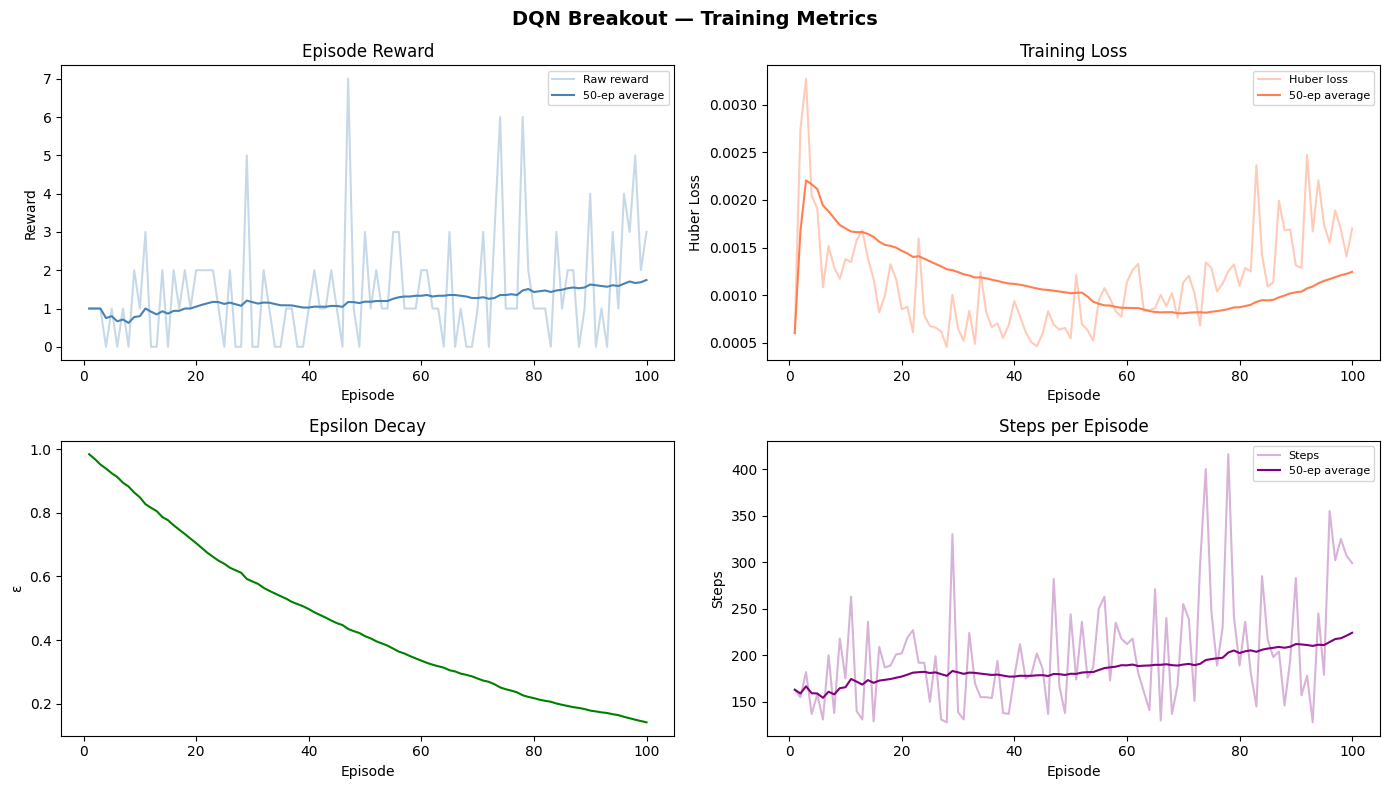

Metrics saved to dqn_breakout_metrics.png


In [10]:
def plot_results(reward_history, loss_history, epsilon_history, steps_history,
                 window: int = 50):
    """Four-panel figure: rewards, loss, epsilon decay, steps per episode."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("DQN Breakout — Training Metrics", fontsize=14, fontweight="bold")

    episodes = range(1, len(reward_history) + 1)

    def rolling_avg(data, w):
        return [np.mean(data[max(0, i-w):i+1]) for i in range(len(data))]

    ax = axes[0, 0]
    ax.plot(episodes, reward_history, alpha=0.3, color="steelblue", label="Raw reward")
    ax.plot(episodes, rolling_avg(reward_history, window),
            color="steelblue", label=f"{window}-ep average")
    ax.set(title="Episode Reward", xlabel="Episode", ylabel="Reward")
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    ax.plot(episodes, loss_history, alpha=0.4, color="coral", label="Huber loss")
    ax.plot(episodes, rolling_avg(loss_history, window),
            color="coral", label=f"{window}-ep average")
    ax.set(title="Training Loss", xlabel="Episode", ylabel="Huber Loss")
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    ax.plot(episodes, epsilon_history, color="green")
    ax.set(title="Epsilon Decay", xlabel="Episode", ylabel="ε")

    ax = axes[1, 1]
    ax.plot(episodes, steps_history, alpha=0.3, color="purple", label="Steps")
    ax.plot(episodes, rolling_avg(steps_history, window),
            color="purple", label=f"{window}-ep average")
    ax.set(title="Steps per Episode", xlabel="Episode", ylabel="Steps")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("dqn_breakout_metrics.png", dpi=150)
    plt.show()
    print("Metrics saved to dqn_breakout_metrics.png")


plot_results(rewards, losses, epsilons, steps)

In [12]:
from pyvirtualdisplay import Display
import imageio
from IPython.display import HTML
from base64 import b64encode

# Start virtual display (Colab has no screen)
display = Display(visible=False, size=(800, 600))
display.start()


def record_agent(agent, env_id="ALE/Breakout-v5",
                 n_episodes=3, filepath="agent_play.mp4"):
    """
    Runs the trained agent for n_episodes, captures every frame,
    and saves them as an mp4 video.
    """
    record_env = gym.make(env_id, render_mode="rgb_array")
    record_env = FramePreprocessor(record_env)
    record_env = FrameStacker(record_env, n_frames=4)

    saved_epsilon = agent.epsilon
    agent.epsilon = 0.0  # pure exploitation — no random actions

    frames = []
    total_rewards = []

    for ep in range(n_episodes):
        state, _ = record_env.reset()
        ep_reward = 0.0

        for _ in range(10_000):
            raw_frame = record_env.env.env.render()  # unwrap to get RGB array
            frames.append(raw_frame)

            action = agent.select_action(state)
            state, reward, terminated, truncated, _ = record_env.step(action)
            ep_reward += reward

            if terminated or truncated:
                break

        total_rewards.append(ep_reward)
        print(f"Recorded episode {ep+1}: reward = {ep_reward:.1f}")

    record_env.close()
    agent.epsilon = saved_epsilon

    print(f"\nSaving video to {filepath} ...")
    imageio.mimsave(filepath, frames, fps=30)
    print(f"Done! Average reward: {np.mean(total_rewards):.2f}")
    return filepath


def show_video(filepath):
    """Embeds an mp4 video directly in the Colab notebook output."""
    with open(filepath, "rb") as f:
        video_data = f.read()
    encoded = b64encode(video_data).decode("ascii")
    html = f"""
    <video width="420" height="320" controls autoplay loop>
        <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
    </video>
    """
    return HTML(html)


video_path = record_agent(agent, n_episodes=3)
show_video(video_path)

Recorded episode 1: reward = 2.0
Recorded episode 2: reward = 4.0
Recorded episode 3: reward = 2.0

Saving video to agent_play.mp4 ...


Done! Average reward: 2.67


In [13]:
from google.colab import files

files.download("dqn_breakout.pth")          # trained model weights
files.download("dqn_breakout_metrics.png")  # training metrics chart
files.download("agent_play.mp4")            # gameplay video

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>